# 03 - Entrenamiento (Fine-tuning de DistilBERT)

Este notebook realiza el fine-tuning de **DistilBERT** para clasificación binaria de discurso de odio (`Hate` / `NotHate`), utilizando `data/processed/dataset.csv`.

**Esquema de etiqueta utilizado:** binario (`label_binary`), según la decisión documentada en el EDA y el README.

**Regularización aplicada:**
- Dropout (incluido por defecto en DistilBERT)
- Weight decay
- Early stopping basado en la métrica de validación
- Class weights en la función de pérdida (para mitigar el desbalance ~75/25)

## Instalación del transformer

In [3]:
!pip install transformers datasets accelerate -q

In [4]:
!pip uninstall -y torchvision -q

In [5]:
import torch

print(f"GPU disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Dispositivo: {torch.cuda.get_device_name(0)}")


GPU disponible: True
Dispositivo: Tesla T4


In [6]:
from google.colab import files

uploaded = files.upload()  # selecciona data/processed/dataset.csv desde tu equipo

PROCESSED_DIR = "."
CHECKPOINT_DIR = "./checkpoints"
LOG_DIR = "./logs"


Saving dataset.csv to dataset (1).csv


## 1. Configuración e importación de librerías

In [7]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from datasets import Dataset
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128
SEED = 42

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")


Usando dispositivo: cuda


## 2. Cargar el dataset procesado

In [8]:
df = pd.read_csv(f"{PROCESSED_DIR}/dataset.csv")

# Nos quedamos solo con las columnas necesarias para el esquema binario
df = df[["id", "text", "label_binary", "split"]].dropna(subset=["label_binary"])
df["label_binary"] = df["label_binary"].astype(int)

print(df.shape)
print(df["split"].value_counts())
print(df["label_binary"].value_counts())


(149823, 4)
split
train    134823
test      10000
val        5000
Name: count, dtype: int64
label_binary
0    112852
1     36971
Name: count, dtype: int64


## 3. Separar en train / val / test según los splits oficiales

In [9]:
train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Train: 134823 | Val: 5000 | Test: 10000


## 4. Calcular class weights

Como `train` tiene un desbalance moderado (~75% NotHate / ~25% Hate), calculamos pesos por clase para que la función de pérdida penalice más los errores sobre la clase minoritaria (`Hate`).

In [10]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label_binary"].values,
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"Class weights (NotHate, Hate): {class_weights}")


Class weights (NotHate, Hate): [0.6398692  2.28738421]


## 5. Tokenización

In [11]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

train_ds = Dataset.from_pandas(train_df[["text", "label_binary"]].rename(columns={"label_binary": "labels"}))
val_ds   = Dataset.from_pandas(val_df[["text", "label_binary"]].rename(columns={"label_binary": "labels"}))
test_ds  = Dataset.from_pandas(test_df[["text", "label_binary"]].rename(columns={"label_binary": "labels"}))

train_ds = train_ds.map(tokenize_function, batched=True)
val_ds   = val_ds.map(tokenize_function, batched=True)
test_ds  = test_ds.map(tokenize_function, batched=True)

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])


Map:   0%|          | 0/134823 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

## 6. Cargar el modelo preentrenado

In [12]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
)
model.to(device)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


## 7. Trainer con pérdida ponderada (class weights)

Se sobreescribe `compute_loss` para aplicar `CrossEntropyLoss` con los pesos de clase calculados anteriormente.

In [13]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


## 8. Métricas de evaluación

In [14]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


## 9. Configuración del entrenamiento (regularización)

- `weight_decay`: regularización L2 sobre los pesos del modelo.
- `load_best_model_at_end` + `EarlyStoppingCallback`: detiene el entrenamiento si la métrica de validación (F1) deja de mejorar, evitando sobreajuste.
- Dropout ya viene incorporado por defecto en la arquitectura de DistilBERT.

In [15]:
training_args = TrainingArguments(
    output_dir=f"{CHECKPOINT_DIR}/distilbert-hate-speech",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir=LOG_DIR,
    logging_steps=100,
    seed=SEED,
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)


[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


## 10. Entrenar el modelo

In [16]:
train_result = trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.595218,0.641362,0.695800,0.709332,0.663065,0.685419
2,0.592416,0.670661,0.683800,0.740818,0.565026,0.641090
3,0.566242,0.777312,0.664400,0.743620,0.501401,0.598948


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## 11. Curvas de entrenamiento (loss train vs. validación)

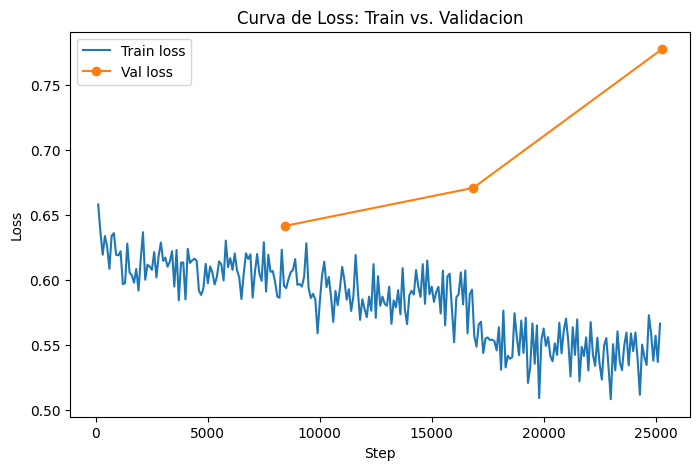

In [17]:
import matplotlib.pyplot as plt

history = trainer.state.log_history
train_loss = [(h["step"], h["loss"]) for h in history if "loss" in h]
eval_loss  = [(h["step"], h["eval_loss"]) for h in history if "eval_loss" in h]

plt.figure(figsize=(8, 5))
if train_loss:
    steps, losses = zip(*train_loss)
    plt.plot(steps, losses, label="Train loss")
if eval_loss:
    steps, losses = zip(*eval_loss)
    plt.plot(steps, losses, label="Val loss", marker="o")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Curva de Loss: Train vs. Validacion")
plt.legend()
plt.show()


## 12. Guardar el modelo entrenado

**Nota:** los checkpoints y pesos del modelo están excluidos del repositorio mediante `.gitignore` (pueden pesar varios GB). Este paso guarda el modelo localmente para su uso en `04_evaluate.ipynb`.

In [18]:
trainer.save_model(f"{CHECKPOINT_DIR}/distilbert-hate-speech-final")
tokenizer.save_pretrained(f"{CHECKPOINT_DIR}/distilbert-hate-speech-final")
print("Modelo guardado en ../checkpoints/distilbert-hate-speech-final")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado en ../checkpoints/distilbert-hate-speech-final
